# Notebook 06 — Modelo Monte Carlo del valor económico y pricing basado en valor

Traduce la reducción de inasistencias en una **distribución de valor mensual recuperado**
para una clínica privada española, y deriva las tres tarifas de aiXtensa (fijo + variable)
ancladas a los percentiles P10/P50/P90 de esa distribución. Cierra el Objetivo 4 de la
propuesta registrada.

**Parámetro de efecto.** El análisis causal (NB04) concluyó que el efecto del SMS no es
identificable de forma estable con los datos observacionales. Por tanto, el efecto NO se
toma de la estimación propia, sino de la **evidencia experimental publicada**, modelado
como una reducción relativa del no-show (escenarios informados por literatura, no una
distribución estadísticamente estimada). El resultado de NB04 queda como evidencia de
no-identificabilidad y como argumento para medir el efecto con un A/B en el propio servicio.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import Image, display

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ))

import logging
from src import pricing, rutas

logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s",
                    datefmt="%H:%M:%S")

## 1. Parámetros del modelo

Cada parámetro se modela como una distribución (triangular: mínimo, moda, máximo; o
uniforme). Se distingue explícitamente entre **datos verificados** y **supuestos declarados**:

| Parámetro | Distribución | Origen |
|---|---|---|
| Reducción relativa del no-show | Triangular(0,18 · 0,25 · 0,335) | Literatura experimental (Robotham 2016; Cochrane 2013) |
| Tasa basal de no-show | Triangular(0,10 · 0,125 · 0,20) | Hernández-García 2018 (12,5%) + rango sectorial |
| Valor de la consulta (€) | Triangular(60 · 100 · 160) | Tarifas verificadas de clínicas privadas (jun. 2026) |
| Coste del SMS (€) | Triangular(0,034 · 0,045 · 0,096) | Esendex / LabsMobile (jun. 2026) |
| Volumen mensual de citas | Uniforme(200 · 800) | **Supuesto declarado** |
| Margen de contribución | Triangular(0,60 · 0,75 · 0,90) | **Supuesto declarado** |

**Anclajes de la reducción relativa:** mínimo = límite del IC95% del RR de no-show de
Robotham 2016 (0,82); moda = "25% less likely to no-show" (RR 0,75, Robotham 2016);
máximo = reducción entre brazos de la Cochrane (32,2% → 21,4%). La reducción relativa
transporta a España mejor que una diferencia absoluta en pp, porque la evidencia procede
de contextos con tasa basal del 21–32%, distinta de la española (~12,5%).

In [2]:
params = pricing.ParametrosMonteCarlo()
print("Parámetros del Monte Carlo (escenario SMS uniforme, share_targeted=1.0):")
for k, v in vars(params).items():
    print(f"  {k}: {v}")

Parámetros del Monte Carlo (escenario SMS uniforme, share_targeted=1.0):
  reduccion_min: 0.18
  reduccion_moda: 0.25
  reduccion_max: 0.335
  basal_min: 0.1
  basal_moda: 0.125
  basal_max: 0.2
  valor_min: 60.0
  valor_moda: 100.0
  valor_max: 160.0
  sms_min: 0.034
  sms_moda: 0.045
  sms_max: 0.096
  volumen_min: 200.0
  volumen_max: 800.0
  margen_min: 0.6
  margen_moda: 0.75
  margen_max: 0.9
  share_targeted: 1.0
  fixed_pct: 0.2
  operational_floor: 50.0
  variable_conservador: 0.1
  variable_recomendado: 0.15
  variable_premium: 0.2


## 2. Simulación (10.000 iteraciones)

Por iteración: `citas_tratadas = volumen × share`; `citas_recuperadas = tratadas × basal ×
reducción_relativa`; `valor_bruto = recuperadas × valor_consulta × margen`;
`coste = tratadas × coste_sms`; `valor_neto = bruto − coste`.

> **Nota metodológica.** Aquí se multiplica `tasa_basal × reducción_relativa`. Esto NO es el
> error de "multiplicar el ATE por la tasa basal": el ATE sería un efecto ya absoluto (en pp),
> mientras que aquí el parámetro es una reducción *relativa* de la literatura, y multiplicarla
> por la basal es precisamente cómo se obtiene la reducción absoluta de no-shows.

In [3]:
sim = pricing.simular(params)
print(f"Iteraciones: {len(sim):,}")
sim[["citas_recuperadas", "valor_bruto", "coste_comunicacion", "valor_neto"]].describe().round(1)

12:02:52 [INFO] Monte Carlo: 10000 iteraciones. Valor neto mensual P50=1304€ (P10=659€, P90=2318€).


Iteraciones: 10,000


,citas_recuperadas,valor_bruto,coste_comunicacion,valor_neto
count,10000.0,10000.0,10000.0,10000.0
mean,18.0,1438.5,29.0,1409.6
std,7.3,665.5,12.3,658.0
min,4.5,245.0,7.1,236.1
25%,12.2,922.9,19.2,900.9
50%,17.4,1333.5,27.4,1303.8
75%,22.9,1833.9,36.6,1797.9
max,49.8,4650.8,75.0,4602.6


## 3. Distribución del valor neto mensual recuperado

La salida del modelo no es un número puntual, sino una distribución que incorpora tanto la
incertidumbre del efecto (rango de literatura) como la del mercado español (precios, volumen,
coste). Se resume con P10/P50/P90.

12:02:52 [INFO] Histograma de valor guardado en /Users/sergi/Library/CloudStorage/OneDrive-Personal/Documentos/TFG Analytics Scripts/Kaggle Processor/outputs/figuras/nb06_distribucion_valor_v1.png.


Valor neto mensual recuperado por clínica (€):
  p10: 659.4 €
  p25: 900.9 €
  p50: 1,303.8 €
  p75: 1,797.9 €
  p90: 2,318.1 €
  media: 1,409.6 €
  pct_negativo: 0.0  (fracción de iteraciones < 0)


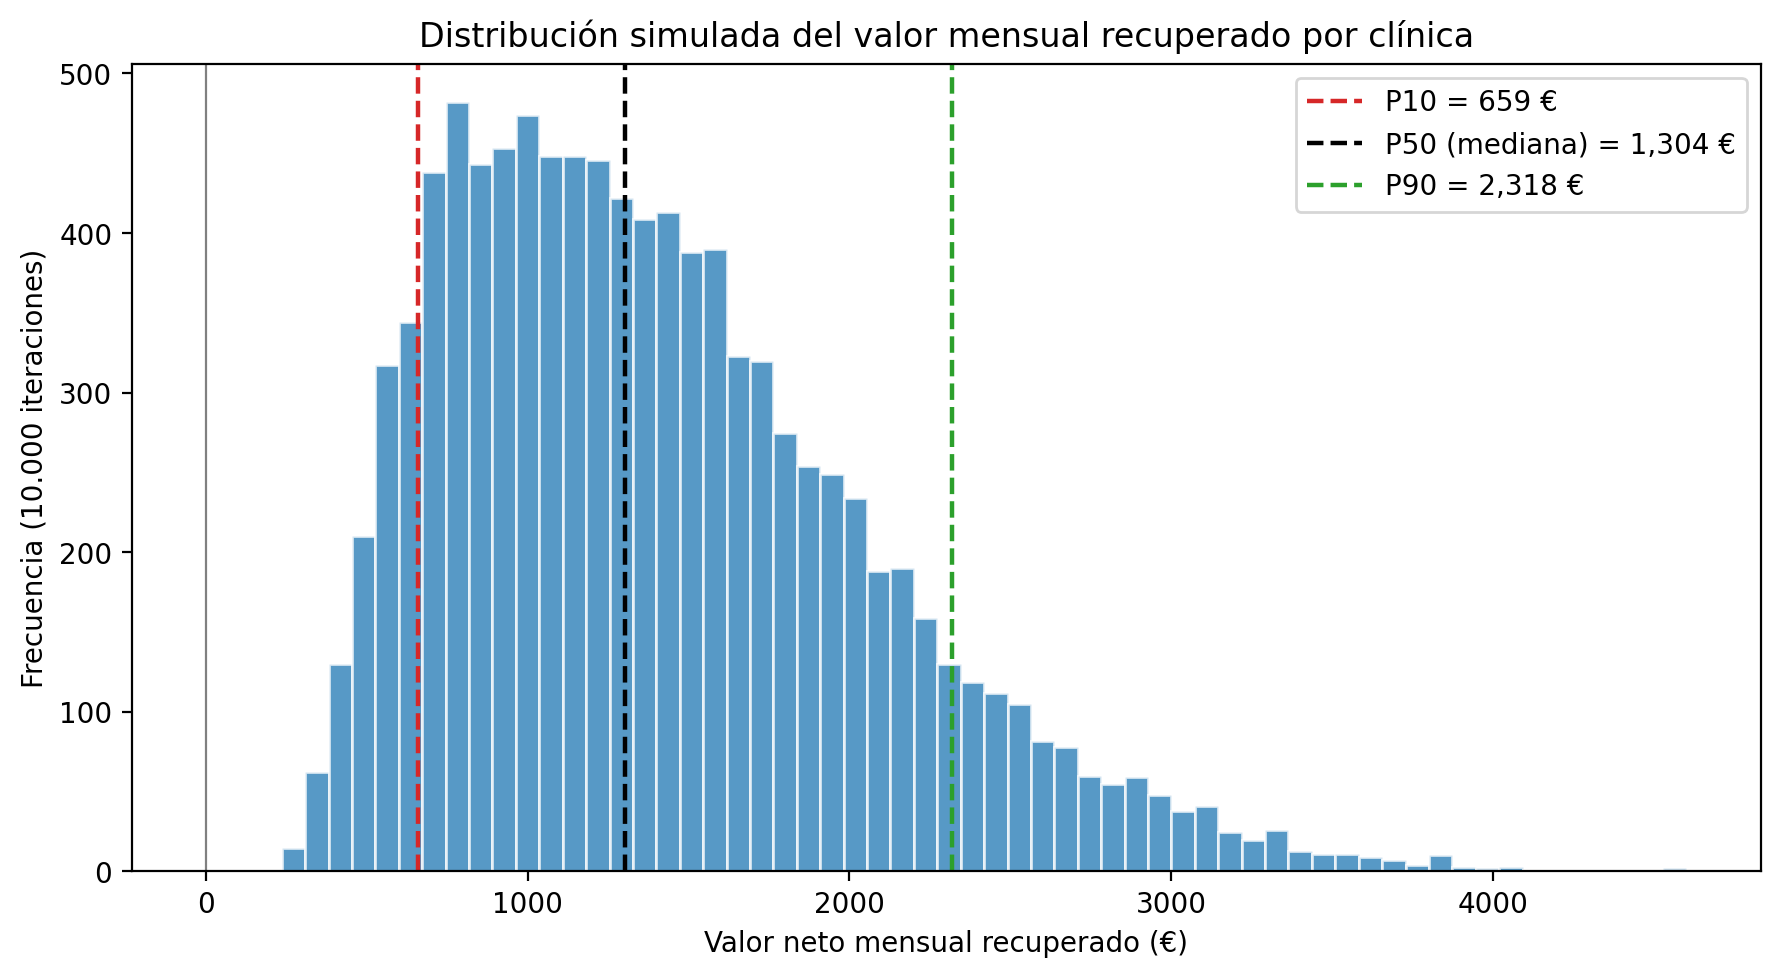

In [4]:
pct = pricing.resumen_percentiles(sim["valor_neto"].to_numpy())
print("Valor neto mensual recuperado por clínica (€):")
for k, v in pct.items():
    print(f"  {k}: {v:,.1f}" + (" €" if k != "pct_negativo" else "  (fracción de iteraciones < 0)"))

fig_valor = rutas.FIGURAS / "nb06_distribucion_valor_v1.png"
pricing.plot_distribucion_valor(sim["valor_neto"].to_numpy(), pct, fig_valor)
display(Image(str(fig_valor), width=750))

**Lectura.** El valor recuperado es, por construcción, una *fracción* del coste total de las
inasistencias: se recupera en torno al 25% de las ausencias (la reducción relativa de la
literatura), no su totalidad. El P50 (~1.300 €/mes) es coherente con esa lógica — a estos
parámetros la pérdida total por no-shows ronda los 2.500–7.500 €/mes que recoge la prensa económica
sectorial (El Independiente, 2025), y recuperar ~un cuarto de ella sitúa el valor neto donde lo hace la simulación.
El P10 acota el escenario pesimista (tasa basal baja, efecto pequeño, consulta barata y
volumen reducido) y el P90 el optimista. La fracción de iteraciones con valor neto negativo
indica con qué frecuencia el coste de los SMS no se compensa.

## 4. Tarifas basadas en valor (fijo + variable)

La propuesta registrada (Obj. 4) compromete una regla **fijo + variable**, no solo bandas de
precio. El componente fijo se ancla a un porcentaje del percentil de valor neto del plan; el
variable es un porcentaje del valor efectivamente recuperado, lo que alinea los ingresos de
aiXtensa con los resultados reales del cliente.

In [5]:
tarifas = pricing.derivar_tarifas(pct, params)
print(tarifas.to_string(index=False))

ruta_csv = rutas.REPORTES / "nb06_tarifas_v1.csv"
tarifas.to_csv(ruta_csv, index=False)
print(f"\nTarifas guardadas en {ruta_csv.name}")

       plan  percentil_valor_neto_eur  cuota_fija_eur_mes  componente_variable_pct
Conservador                    659.42              131.88                       10
Recomendado                   1303.84              260.77                       15
    Premium                   2318.15              463.63                       20

Tarifas guardadas en nb06_tarifas_v1.csv


**Lectura.** Las tres tarifas no son arbitrarias: cada cuota fija es el 20% del percentil
correspondiente de la distribución simulada (el suelo operativo solo actuaría para el
Conservador en escenarios degenerados donde el P10 fuese muy pequeño). Sobre el fijo se monta
una gradación de servicio (recordatorio básico + informe → recordatorios + dashboard →
recordatorios + escalado + soporte), pero el **precio sigue anclado a P10/P50/P90**, que es
lo que lo hace pricing basado en valor y no una tarifa inventada.

## 5. Sensibilidad: ¿de qué depende el valor recuperado?

Correlación de cada parámetro de entrada con el valor neto, para identificar los drivers.

In [6]:
drivers = ["reduccion_relativa", "tasa_basal", "valor_consulta", "volumen_mensual",
           "margen", "coste_sms"]
corr = sim[drivers + ["valor_neto"]].corr()["valor_neto"].drop("valor_neto").sort_values()
print("Correlación con el valor neto mensual:")
print(corr.round(3).to_string())

Correlación con el valor neto mensual:
coste_sms            -0.006
margen                0.163
reduccion_relativa    0.270
tasa_basal            0.318
valor_consulta        0.432
volumen_mensual       0.744


**Lectura.** El valor recuperado está gobernado por los parámetros de escala (volumen,
valor de la consulta, margen) y por el efecto (reducción × basal); el coste del SMS es
marginal. Esto refuerza el mensaje de negocio: el retorno es robusto al precio exacto del
SMS y sensible, sobre todo, al tamaño y precio medio de la clínica — variables que el cliente
conoce y que la calculadora ROI puede personalizar.

## 6. Persistencia

Sidecar con parámetros, percentiles y tarifas para la memoria y la calculadora ROI.

In [7]:
sidecar = {
    "notebook": "06_pricing_montecarlo",
    "n_iteraciones": int(pricing.N_ITER),
    "seed": int(pricing.SEED_MONTECARLO),
    "escenario": "SMS uniforme (share_targeted=1.0)",
    "parametros": vars(params),
    "percentiles_valor_neto": pct,
    "tarifas": tarifas.to_dict(orient="records"),
    "fuente_efecto": ("Reducción relativa del no-show de literatura experimental "
                      "(Robotham 2016; Gurol-Urganci 2013). NO se usa la estimación "
                      "causal propia de NB04 por no ser identificable de forma estable."),
    "escenarios_pendientes": ("SMS dirigido y SMS + escalado multicanal dependen de los "
                              "clústeres de NB05; se incorporan cuando NB05 esté disponible."),
}
import json
ruta_sidecar = rutas.REPORTES / "nb06_metadatos_v1.json"
pricing.persistir_sidecar(sidecar, ruta_sidecar)
print(f"Sidecar guardado en {ruta_sidecar.name}")

12:02:52 [INFO] Sidecar guardado en /Users/sergi/Library/CloudStorage/OneDrive-Personal/Documentos/TFG Analytics Scripts/Kaggle Processor/outputs/reportes/nb06_metadatos_v1.json.


Sidecar guardado en nb06_metadatos_v1.json


## 7. Conclusiones

1. El valor mensual recuperado se expresa como una distribución simulada que combina la
   incertidumbre del efecto (rango de literatura) y la del mercado español (precios, volumen,
   coste), no como un punto.
2. Las tres tarifas (Conservador / Recomendado / Premium) se derivan como pares fijo +
   variable anclados a P10/P50/P90, cumpliendo verbatim el Objetivo 4 registrado.
3. El parámetro de efecto procede de evidencia experimental, no de la estimación causal
   propia (no identificable, NB04). Es una decisión deliberada y declarada, más defendible
   que forzar un efecto observacional inestable.
4. Los escenarios dirigido y multicanal quedan condicionados a la segmentación de NB05.

In [8]:
# Verificación final
assert (sim["valor_neto"] > sim["valor_bruto"]).sum() == 0, "neto no puede superar al bruto"
assert pct["p10"] <= pct["p50"] <= pct["p90"], "percentiles deben ser monótonos"
assert len(tarifas) == 3, "deben derivarse tres tarifas"
print("Checklist NB06: OK")
print("NB06 completo.")

Checklist NB06: OK
NB06 completo.
